In [1]:
import pandas as pd
import os
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
#Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

In [3]:
#Ensure NLTK stopwords are available
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hachikaruanyakwee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
#Define file paths
sentiment_dir = os.path.join("..", "data", "sentiment")
output_file = os.path.join(sentiment_dir, "neutral_words_analysis.csv")

In [5]:
#Load dataset
logging.info(f"Loading sentiment analysis results from: {os.path.join(sentiment_dir, 'sentiment_analysis.csv')}")
df = pd.read_csv(os.path.join(sentiment_dir, "sentiment_analysis.csv"))

2025-03-23 10:25:15,216 - INFO - Loading sentiment analysis results from: ../data/sentiment/sentiment_analysis.csv


In [6]:
#Ensure required columns exist
if "final_sentiment" not in df.columns or "text" not in df.columns:
    raise ValueError("Missing required columns ('final_sentiment' and 'text') in sentiment dataset!")

In [7]:
#Filter Neutral Comments
neutral_df = df[df["final_sentiment"] == "Neutral"]
logging.info(f"Found {len(neutral_df)} neutral comments.")

2025-03-23 10:25:15,229 - INFO - Found 899 neutral comments.


In [8]:
#Combine all neutral text into a single string
text_data = " ".join(neutral_df["text"].dropna())

In [9]:
#Tokenization & Stopword Removal
stop_words = set(stopwords.words("english"))
words = word_tokenize(text_data)
words = [word.lower() for word in words if word.isalnum() and word.lower() not in stop_words]

In [10]:
#Word Frequency Analysis
word_counts = Counter(words)
common_words = word_counts.most_common(50)
df_common_words = pd.DataFrame(common_words, columns=["Word", "Frequency"])
df_common_words.to_csv(output_file, index=False)

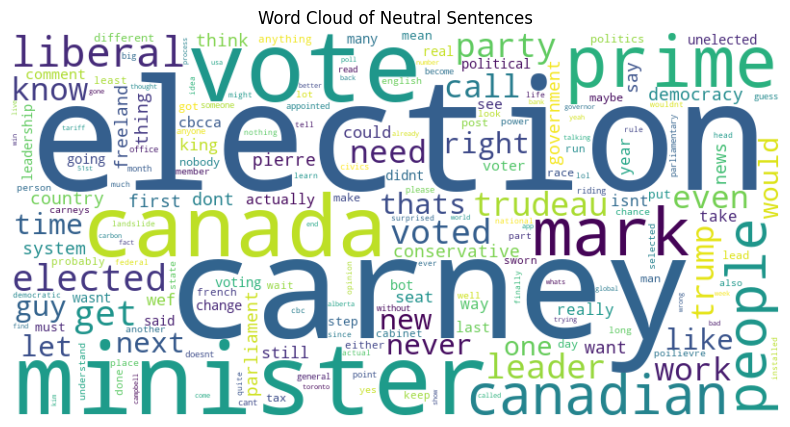

2025-03-23 10:25:15,855 - INFO - ✅ Word cloud for neutral comments saved!


In [11]:
#Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Neutral Sentences")
plt.savefig(os.path.join(sentiment_dir, "neutral_wordcloud.png"))
plt.show()
plt.close()
logging.info("✅ Word cloud for neutral comments saved!")

/var/folders/wc/lj0_3jjn1zv0_y7s7thm5jqw0000gn/T/ipykernel_70367/1425109748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_common_words["Frequency"][:20], y=df_common_words["Word"][:20], palette="coolwarm")


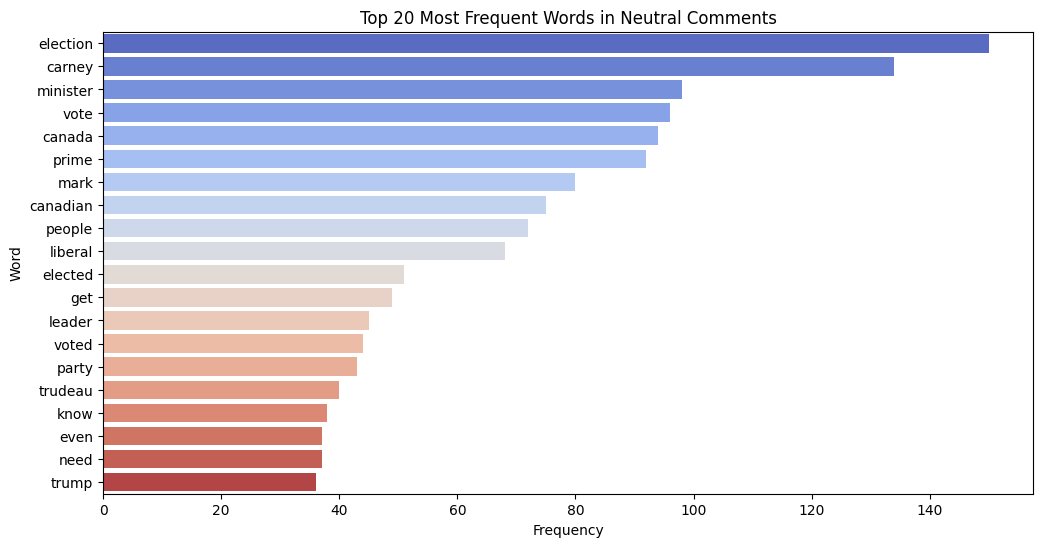

2025-03-23 10:25:16,145 - INFO - 📊 Word frequency analysis plot saved!


In [12]:
#Plot Top 20 Common Words
plt.figure(figsize=(12, 6))
sns.barplot(x=df_common_words["Frequency"][:20], y=df_common_words["Word"][:20], palette="coolwarm")
plt.title("Top 20 Most Frequent Words in Neutral Comments")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.savefig(os.path.join(sentiment_dir, "neutral_word_frequency.png"))
plt.show()
plt.close()
logging.info("📊 Word frequency analysis plot saved!")

In [13]:
logging.info("✅ Neutral comment analysis complete!")

2025-03-23 10:25:16,149 - INFO - ✅ Neutral comment analysis complete!
